# 📊 Daily Summary - Analiza Danych Wejściowych

**Data utworzenia:** 2026-01-13  
**Cel:** Zrozumieć jakie dane są używane do generowania Daily Summary

## Pytania do zbadania:

1. **Artykuły:**
   - Jakie daty `published_at` są brane do summary?
   - Z jakich źródeł pochodzą artykuły?
   - Jakie kategorie są reprezentowane?
   - Ile artykułów jest przetworzonych vs nieprzetworzonych?

2. **Wydarzenia:**
   - Jakie daty `event_date` są brane do summary?
   - Z jakich artykułów pochodzą wydarzenia?
   - Jakie lokalizacje?

3. **Pogoda:**
   - Które rekordy pogody są aktualne (`is_current=True`)?
   - Kiedy były ostatnio pobrane?

---

## Logika Summary Generator (z kodu)

```python
# 1. Artykuły (linie 74-81):
#    - published_at >= date_start (np. 2026-01-12 00:00)
#    - published_at < date_end (np. 2026-01-13 00:00)
#    - processed == True

# 2. Wydarzenia (linie 95-105):
#    - event_date >= events_start (date_end, np. 2026-01-13 00:00)
#    - event_date < events_end (events_start + 7 days)
#    - LIMIT 10

# 3. Pogoda (linie 107-114):
#    - is_current == True
#    - ORDER BY fetched_at DESC
#    - LIMIT 1
```

In [2]:
# Setup
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Dodaj backend do path
backend_path = Path.cwd().parent
sys.path.insert(0, str(backend_path))

from database_helper import get_database_connection, Article, Source
from sqlmodel import Session, select, func, and_
from sqlalchemy import Column, Integer, String, Boolean, DateTime, ARRAY, JSON
from sqlalchemy.dialects.postgresql import JSONB
from sqlmodel import SQLModel, Field
from typing import Optional, List

# Definiuj modele które nie ma w database_helper
class Event(SQLModel, table=True):
    __tablename__ = "events"
    id: Optional[int] = Field(default=None, primary_key=True)
    title: str = Field(max_length=500)
    description: Optional[str] = None
    short_description: Optional[str] = Field(default=None, max_length=300)
    event_date: datetime
    event_time: Optional[str] = Field(default=None, max_length=10)
    end_date: Optional[datetime] = None
    location: Optional[str] = Field(default=None, max_length=255)
    address: Optional[str] = None
    category: Optional[str] = Field(default=None, max_length=100)
    source_article_id: Optional[int] = Field(default=None, foreign_key="articles.id")
    external_url: Optional[str] = None
    image_url: Optional[str] = None
    organizer: Optional[str] = Field(default=None, max_length=255)
    price_info: Optional[str] = Field(default=None, max_length=255)
    contact_info: Optional[str] = None
    created_at: datetime = Field(default_factory=datetime.utcnow)
    updated_at: datetime = Field(default_factory=datetime.utcnow)
    is_featured: bool = Field(default=False)
    views_count: int = Field(default=0)

class Weather(SQLModel, table=True):
    __tablename__ = "weather"
    id: Optional[int] = Field(default=None, primary_key=True)
    location: str = Field(max_length=100, index=True)
    latitude: float
    longitude: float
    temperature: float
    feels_like: float
    temp_min: float
    temp_max: float
    description: str = Field(max_length=200)
    icon: str = Field(max_length=10)
    main: str = Field(max_length=50)
    humidity: int
    pressure: int
    wind_speed: float
    wind_deg: Optional[int] = None
    clouds: int
    visibility: Optional[int] = None
    rain_1h: Optional[float] = None
    rain_3h: Optional[float] = None
    sunrise: Optional[datetime] = None
    sunset: Optional[datetime] = None
    forecast: Optional[dict] = Field(default=None, sa_column=Column(JSONB))
    fetched_at: datetime = Field(default_factory=datetime.utcnow, index=True)
    is_current: bool = Field(default=True)

class DailySummary(SQLModel, table=True):
    __tablename__ = "daily_summaries"
    id: Optional[int] = Field(default=None, primary_key=True)
    date: datetime = Field(index=True, unique=True)
    headline: str = Field(max_length=500)
    content: dict = Field(sa_column=Column(JSONB))
    generated_at: datetime = Field(default_factory=datetime.utcnow)

# Konfiguracja wizualizacji
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Setup completed")

✓ Setup completed


In [3]:
# Połącz z bazą danych
from src.config import settings

engine = get_database_connection(settings.DATABASE_URL)
session = Session(engine)

print(f"✓ Connected to database: {settings.DATABASE_URL.split('@')[1]}")

✓ Connected to database: localhost:5432/centrum_operacyjne


---

## 📰 Część 1: Analiza Artykułów

In [4]:
# Pobierz wszystkie artykuły
all_articles = session.exec(select(Article)).all()
df_articles = pd.DataFrame([{
    'id': a.id,
    'source_id': a.source_id,
    'title': a.title,
    'published_at': a.published_at,
    'scraped_at': a.scraped_at,
    'category': a.category,
    'processed': a.processed,
    'tags': a.tags,
    'location_mentioned': a.location_mentioned
} for a in all_articles])

print(f"Total articles in database: {len(df_articles)}")
print(f"Processed articles: {df_articles['processed'].sum()}")
print(f"Unprocessed articles: {(~df_articles['processed']).sum()}")
df_articles.head()

Total articles in database: 164
Processed articles: 77
Unprocessed articles: 87


,id,source_id,title,published_at,scraped_at,category,processed,tags,location_mentioned
0,270,1,Kradzieże pieniędzy o łącznej sumie ponad 130 ...,2025-12-07 00:00:00,2026-01-13 10:33:59.765495,None,False,None,None
1,285,1,Największa zjeżdżalnia wodna w Polsce! Powstan...,2025-03-31 00:00:00,2026-01-13 10:33:59.804915,None,False,None,None
2,389,6,Informacja dla Mieszkańców!\n\nCentrum Usług S...,2026-01-07 10:27:24,2026-01-13 10:35:47.092762,Zdrowie,True,"[ZUS, społeczność, emerytura, spotkania, Dział...",[Działdowo]
3,397,6,💻 Pierwsze laptopy odebrane!\n🚚 Rozpoczęły się...,2025-12-16 09:16:21,2026-01-11 20:57:18.952889,Edukacja,True,"[laptopy, szkoły, sprzęt edukacyjny, nauczanie...","[Rybno, Działdowo, Lidzbark, Iłowo-Osada, Płoś..."
4,356,3,"Pogadajmy o przyrodzie - Pomrowy, pomrowiki, p...",2025-10-15 00:00:00,2026-01-13 10:34:11.839482,None,False,None,None


In [6]:
# Analiza dat publikacji
df_articles['published_date'] = pd.to_datetime(df_articles['published_at']).dt.date
df_articles['scraped_date'] = pd.to_datetime(df_articles['scraped_at']).dt.date

print("PUBLISHED_AT - Rozkład Dat")
print("=" * 80)
published_counts = df_articles.groupby('published_date').size().sort_index()
print(published_counts)

print("\n" + "=" * 80)
print("SCRAPED_AT - Rozkład Dat")
print("=" * 80)
scraped_counts = df_articles.groupby('scraped_date').size().sort_index()
print(scraped_counts)

PUBLISHED_AT - Rozkład Dat
published_date
2011-06-13     1
2011-07-11     1
2015-03-24     1
2015-08-31     1
2015-09-16     1
              ..
2026-01-09     7
2026-01-10     8
2026-01-11    12
2026-01-12    14
2026-01-13     3
Length: 90, dtype: int64

SCRAPED_AT - Rozkład Dat
scraped_date
2026-01-11     29
2026-01-13    135
dtype: int64


In [ ]:
# Wizualizacja dat publikacji vs scrapingu
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Published dates
published_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Artykuły po dacie PUBLIKACJI (published_at)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Data publikacji')
axes[0].set_ylabel('Liczba artykułów')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Scraped dates
scraped_counts.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Artykuły po dacie SCRAPINGU (scraped_at)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Data scrapingu')
axes[1].set_ylabel('Liczba artykułów')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n⚠️  WAŻNE: Summary Generator używa PUBLISHED_AT (niebieski wykres)")

In [8]:
# Pobierz informacje o źródłach
sources = session.exec(select(Source)).all()
df_sources = pd.DataFrame([{
    'id': s.id,
    'name': s.name,
    'type': s.type,
    'status': s.status,
    'last_scraped': s.last_scraped
} for s in sources])

print("\n" + "=" * 80)
print("ŹRÓDŁA DANYCH")
print("=" * 80)
print(df_sources)

# Połącz artykuły ze źródłami
df_articles_sources = df_articles.merge(
    df_sources[['id', 'name', 'type']], 
    left_on='source_id', 
    right_on='id',
    suffixes=('', '_source')
)

print("\n" + "=" * 80)
print("ARTYKUŁY PO ŹRÓDŁACH")
print("=" * 80)
source_counts = df_articles_sources.groupby('name').agg({
    'id': 'count',
    'processed': 'sum'
}).rename(columns={'id': 'Total', 'processed': 'Processed'})
source_counts['Unprocessed'] = source_counts['Total'] - source_counts['Processed']
print(source_counts)


ŹRÓDŁA DANYCH
   id                               name          type    status  \
0   4           Gmina Działdowo Facebook  social_media  inactive   
1   3                     Moje Działdowo         media    active   
2   5                    Facebook - Syla  social_media    active   
3   6         Facebook - Gmina Działdowo  social_media    active   
4   7  Facebook - Urząd Miasta Działdowo  social_media    active   
5   1                        Klikaj.info         media    active   
6   2                        Gmina Rybno         urząd    active   

                last_scraped  
0                        NaT  
1 2026-01-13 10:34:11.920381  
2 2026-01-13 10:34:42.272257  
3 2026-01-13 10:35:47.131576  
4 2026-01-13 10:35:54.806957  
5 2026-01-13 10:33:59.836805  
6 2026-01-13 10:34:04.424507  

ARTYKUŁY PO ŹRÓDŁACH
                            Total  Processed  Unprocessed
name                                                     
Facebook - Gmina Działdowo     12         11          

In [ ]:
# Wizualizacja artykułów per źródło
fig, ax = plt.subplots(figsize=(10, 6))
source_counts[['Processed', 'Unprocessed']].plot(
    kind='bar', 
    stacked=True, 
    ax=ax,
    color=['green', 'lightgray']
)
ax.set_title('Artykuły per źródło (processed vs unprocessed)', fontsize=14, fontweight='bold')
ax.set_xlabel('Źródło')
ax.set_ylabel('Liczba artykułów')
ax.legend(['Przetworzone (AI)', 'Nieprzetworzone'])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


KATEGORIE (tylko przetworzone artykuły)
category
Kultura          35
Urząd            14
Edukacja          9
Biznes            5
Zdrowie           4
Transport         4
Rekreacja         4
Nieruchomości     2
Name: count, dtype: int64


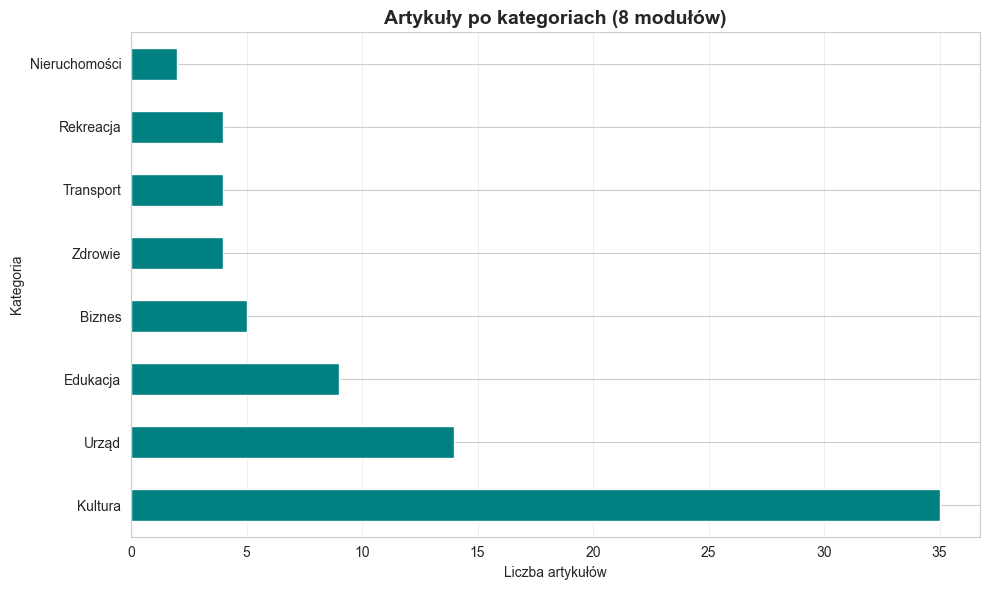

In [14]:
# Analiza kategorii (tylko przetworzone artykuły)
df_processed = df_articles[df_articles['processed'] == True]

print("\n" + "=" * 80)
print("KATEGORIE (tylko przetworzone artykuły)")
print("=" * 80)
category_counts = df_processed['category'].value_counts()
print(category_counts)

# Wykres kategorii
if len(category_counts) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    category_counts.plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Artykuły po kategoriach (8 modułów)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Liczba artykułów')
    ax.set_ylabel('Kategoria')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Brak przetworzonych artykułów z kategoriami")

---

## 🎭 Część 2: Analiza Wydarzeń

In [9]:
# Pobierz wszystkie wydarzenia
all_events = session.exec(select(Event)).all()
df_events = pd.DataFrame([{
    'id': e.id,
    'title': e.title,
    'event_date': e.event_date,
    'event_time': e.event_time,
    'location': e.location,
    'category': e.category,
    'source_article_id': e.source_article_id,
    'created_at': e.created_at
} for e in all_events])

print(f"Total events in database: {len(df_events)}")
if len(df_events) > 0:
    df_events['event_date_only'] = pd.to_datetime(df_events['event_date']).dt.date
    print("\n" + "=" * 80)
    print("WYDARZENIA - Podgląd")
    print("=" * 80)
    print(df_events[['title', 'event_date_only', 'location', 'category']].head(10))
else:
    print("Brak wydarzeń w bazie danych")

Total events in database: 73

WYDARZENIA - Podgląd
                                               title event_date_only  \
0  Liga Halowa w Byszwałdzie o Puchar Wójta Gminy...      2026-01-11   
1                        Licytacje na 34. Finał WOŚP      2026-01-18   
2  VII seria spotkań XXII Edycji Otwartych Mistrz...      2026-01-11   
3            Ślubowanie klas OPW oraz humanistycznej      2026-01-11   
4                   Licytacje na rzecz WOŚP w Rybnie      2026-01-18   
5                              KARNA WOW Celebration      2026-01-10   
6  Głosowanie w Konkursie Fotograficznym "Zima w ...      2026-01-10   
7  VII seria spotkań XXII Edycji Otwartych Mistrz...      2026-01-11   
8             Licytacje na rzecz WOŚP na portalu SiS      2026-01-18   
9  Głosowanie na Konkurs Fotograficzny "Zima w ob...      2026-01-10   

               location  category  
0              Byszwałd   Kultura  
1                 Rybno   Kultura  
2              Byszwałd   Kultura  
3           


WYDARZENIA - Rozkład dat
event_date_only
2025-12-14     2
2025-12-18     2
2025-12-19     4
2025-12-23     3
2025-12-30     1
2026-01-02     2
2026-01-04     4
2026-01-08     1
2026-01-10    16
2026-01-11    17
2026-01-18    16
2026-01-23     1
2026-02-07     1
2026-02-13     1
2026-02-15     1
2026-03-07     1
dtype: int64


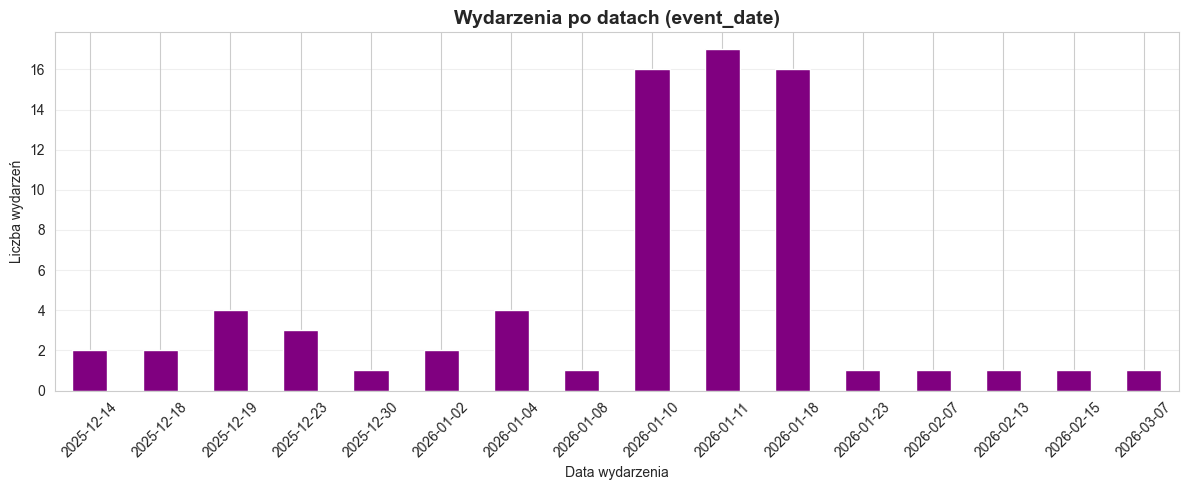


NADCHODZĄCE WYDARZENIA (następne 7 dni: 2026-01-13 - 2026-01-20)
Liczba: 16

Lista:
                                                        title event_date_only          location
                                  Licytacje na 34. Finał WOŚP      2026-01-18             Rybno
                             Licytacje na rzecz WOŚP w Rybnie      2026-01-18             Rybno
                       Licytacje na rzecz WOŚP na portalu SiS      2026-01-18             Rybno
                                      Licytacje WOŚP w Rybnie      2026-01-18             Rybno
                      Licytacje online na rzecz WOŚP w Rybnie      2026-01-18             Rybno
                           Licytacja na rzecz 34. Finału WOŚP      2026-01-18             Rybno
                                  Licytacje na 34. finał WOŚP      2026-01-18             Rybno
                             WOŚP w Rybnie - Licytacje Online      2026-01-18             Rybno
                                Licytacje WOŚP na p

In [10]:
# Analiza dat wydarzeń
if len(df_events) > 0:
    print("\n" + "=" * 80)
    print("WYDARZENIA - Rozkład dat")
    print("=" * 80)
    event_date_counts = df_events.groupby('event_date_only').size().sort_index()
    print(event_date_counts)
    
    # Wykres
    fig, ax = plt.subplots(figsize=(12, 5))
    event_date_counts.plot(kind='bar', ax=ax, color='purple')
    ax.set_title('Wydarzenia po datach (event_date)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Data wydarzenia')
    ax.set_ylabel('Liczba wydarzeń')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Wydarzenia nadchodzące (następne 7 dni)
    today = datetime.now().date()
    next_7_days = today + timedelta(days=7)
    upcoming_events = df_events[
        (df_events['event_date_only'] >= today) & 
        (df_events['event_date_only'] < next_7_days)
    ]
    
    print("\n" + "=" * 80)
    print(f"NADCHODZĄCE WYDARZENIA (następne 7 dni: {today} - {next_7_days})")
    print("=" * 80)
    print(f"Liczba: {len(upcoming_events)}")
    if len(upcoming_events) > 0:
        print("\nLista:")
        print(upcoming_events[['title', 'event_date_only', 'location']].to_string(index=False))
    
    print("\n⚠️  WAŻNE: Summary Generator używa wydarzeń z następnych 7 dni (LIMIT 10)")
else:
    print("Brak wydarzeń do analizy")


WYDARZENIA - Źródła pochodzenia (artykuły)
name
Facebook - Syla               51
Moje Działdowo                15
Facebook - Gmina Działdowo     6
Gmina Rybno                    1
dtype: int64


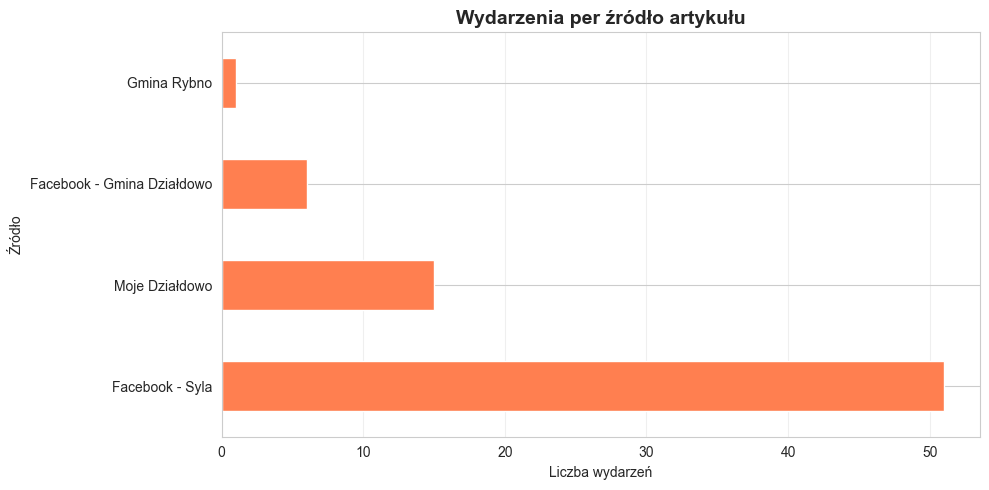

In [11]:
# Analiza źródeł wydarzeń (z jakich artykułów pochodzą)
if len(df_events) > 0 and 'source_article_id' in df_events.columns:
    # Połącz wydarzenia z artykułami
    df_events_sources = df_events.merge(
        df_articles_sources[['id', 'name', 'title']], 
        left_on='source_article_id',
        right_on='id',
        suffixes=('_event', '_article')
    )
    
    print("\n" + "=" * 80)
    print("WYDARZENIA - Źródła pochodzenia (artykuły)")
    print("=" * 80)
    event_source_counts = df_events_sources.groupby('name').size().sort_values(ascending=False)
    print(event_source_counts)
    
    # Wykres
    if len(event_source_counts) > 0:
        fig, ax = plt.subplots(figsize=(10, 5))
        event_source_counts.plot(kind='barh', ax=ax, color='coral')
        ax.set_title('Wydarzenia per źródło artykułu', fontsize=14, fontweight='bold')
        ax.set_xlabel('Liczba wydarzeń')
        ax.set_ylabel('Źródło')
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("Brak danych o źródłach wydarzeń")

---

## 🌤️ Część 3: Analiza Pogody

In [12]:
# Pobierz wszystkie rekordy pogody
all_weather = session.exec(select(Weather)).all()
df_weather = pd.DataFrame([{
    'id': w.id,
    'location': w.location,
    'temperature': w.temperature,
    'description': w.description,
    'humidity': w.humidity,
    'wind_speed': w.wind_speed,
    'fetched_at': w.fetched_at,
    'is_current': w.is_current
} for w in all_weather])

print(f"Total weather records: {len(df_weather)}")
if len(df_weather) > 0:
    df_weather['fetched_date'] = pd.to_datetime(df_weather['fetched_at']).dt.date
    df_weather['fetched_time'] = pd.to_datetime(df_weather['fetched_at']).dt.time
    
    print("\n" + "=" * 80)
    print("POGODA - Podgląd najnowszych rekordów")
    print("=" * 80)
    print(df_weather.sort_values('fetched_at', ascending=False).head(10))

Total weather records: 16

POGODA - Podgląd najnowszych rekordów
    id   location  temperature        description  humidity  wind_speed  \
15  16  Działdowo        -9.12  zachmurzenie duże        89        4.07   
14  15      Rybno        -8.80  zachmurzenie duże        90        2.84   
6   14  Działdowo        -7.61  zachmurzenie duże        90        2.65   
13  13      Rybno        -7.36  zachmurzenie duże        91        2.23   
2   12  Działdowo        -7.49  zachmurzenie duże        91        2.65   
12  11      Rybno        -7.12  zachmurzenie duże        92        2.23   
5   10  Działdowo        -7.46  zachmurzenie duże        91        2.65   
11   9      Rybno        -7.10  zachmurzenie duże        92        2.23   
4    8  Działdowo        -7.08  zachmurzenie duże        89        2.64   
10   7      Rybno        -6.85  zachmurzenie duże        90        2.33   

                   fetched_at  is_current fetched_date     fetched_time  
15 2026-01-08 20:30:33.345644      

In [16]:
# Sprawdź które rekordy są "current"
if len(df_weather) > 0:
    df_current_weather = df_weather[df_weather['is_current'] == True]
    
    print("\n" + "=" * 80)
    print("POGODA - Rekordy z is_current=True")
    print("=" * 80)
    print(f"Liczba: {len(df_current_weather)}")
    if len(df_current_weather) > 0:
        print("\nNajnowszy rekord (ten używany w Summary):")
        latest_weather = df_current_weather.sort_values('fetched_at', ascending=False).iloc[0]
        print(f"  Lokalizacja: {latest_weather['location']}")
        print(f"  Temperatura: {latest_weather['temperature']}°C")
        print(f"  Opis: {latest_weather['description']}")
        print(f"  Wilgotność: {latest_weather['humidity']}%")
        print(f"  Wiatr: {latest_weather['wind_speed']} m/s")
        print(f"  Pobrane: {latest_weather['fetched_at']}")
    else:
        print("Brak rekordów z is_current=True")
    
    print("\n⚠️  WAŻNE: Summary Generator używa najnowszego rekordu z is_current=True")


POGODA - Rekordy z is_current=True
Liczba: 2

Najnowszy rekord (ten używany w Summary):
  Lokalizacja: Działdowo
  Temperatura: -9.12°C
  Opis: zachmurzenie duże
  Wilgotność: 89%
  Wiatr: 4.07 m/s
  Pobrane: 2026-01-08 20:30:33.345644

⚠️  WAŻNE: Summary Generator używa najnowszego rekordu z is_current=True


---

## 📝 Część 4: Symulacja Generowania Summary

In [17]:
# Symuluj logikę summary_generator.py
from datetime import datetime, timedelta

# Określ datę docelową (np. wczoraj lub data z najnowszych artykułów)
if len(df_processed) > 0:
    latest_published = df_processed['published_at'].max()
    target_date = pd.to_datetime(latest_published).replace(hour=0, minute=0, second=0, microsecond=0)
else:
    target_date = datetime.now().replace(hour=0, minute=0, second=0, microsecond=0) - timedelta(days=1)

date_start = target_date
date_end = target_date + timedelta(days=1)

print("=" * 80)
print("SYMULACJA: Jakie dane byłyby użyte do generowania Summary")
print("=" * 80)
print(f"\nTarget date: {target_date.date()}")
print(f"Date range: {date_start} - {date_end}")

# 1. Artykuły z tego dnia
summary_articles = df_processed[
    (pd.to_datetime(df_processed['published_at']) >= date_start) &
    (pd.to_datetime(df_processed['published_at']) < date_end)
]

print(f"\n📰 ARTYKUŁY (published_at w zakresie {date_start.date()} - {date_end.date()}):")
print(f"  Liczba: {len(summary_articles)}")

if len(summary_articles) > 0:
    print("\n  Po kategoriach:")
    cat_counts = summary_articles['category'].value_counts()
    for cat, count in cat_counts.items():
        print(f"    - {cat}: {count}")
    
    print("\n  Po źródłach:")
    summary_articles_sources = summary_articles.merge(
        df_sources[['id', 'name']], 
        left_on='source_id', 
        right_on='id',
        suffixes=('', '_source')
    )
    source_counts_summary = summary_articles_sources['name'].value_counts()
    for source, count in source_counts_summary.items():
        print(f"    - {source}: {count}")
    
    print("\n  Lista tytułów:")
    for idx, row in summary_articles.iterrows():
        print(f"    • {row['title'][:80]}...")
else:
    print("  Brak artykułów w tym zakresie dat")

# 2. Wydarzenia (następne 7 dni od date_end)
events_start = date_end
events_end = events_start + timedelta(days=7)

if len(df_events) > 0:
    summary_events = df_events[
        (df_events['event_date_only'] >= events_start.date()) &
        (df_events['event_date_only'] < events_end.date())
    ].head(10)  # LIMIT 10
    
    print(f"\n🎭 WYDARZENIA (event_date w zakresie {events_start.date()} - {events_end.date()}, LIMIT 10):")
    print(f"  Liczba: {len(summary_events)}")
    
    if len(summary_events) > 0:
        print("\n  Lista:")
        for idx, row in summary_events.iterrows():
            print(f"    • {row['title']} ({row['event_date_only']}, {row['location']})")
else:
    print(f"\n🎭 WYDARZENIA: Brak danych")

# 3. Pogoda (is_current=True, najnowsza)
if len(df_weather) > 0 and len(df_current_weather) > 0:
    summary_weather = df_current_weather.sort_values('fetched_at', ascending=False).iloc[0]
    print(f"\n🌤️  POGODA (is_current=True, najnowsza):")
    print(f"  Lokalizacja: {summary_weather['location']}")
    print(f"  Temperatura: {summary_weather['temperature']}°C")
    print(f"  Opis: {summary_weather['description']}")
    print(f"  Pobrane: {summary_weather['fetched_at']}")
else:
    print(f"\n🌤️  POGODA: Brak danych")

print("\n" + "=" * 80)
print("KONIEC SYMULACJI")
print("=" * 80)

SYMULACJA: Jakie dane byłyby użyte do generowania Summary

Target date: 2026-01-13
Date range: 2026-01-13 00:00:00 - 2026-01-14 00:00:00

📰 ARTYKUŁY (published_at w zakresie 2026-01-13 - 2026-01-14):
  Liczba: 3

  Po kategoriach:
    - Kultura: 2
    - Zdrowie: 1

  Po źródłach:
    - Facebook - Syla: 3

  Lista tytułów:
    • 🩸 Krew pilnie potrzebna – liczy się każda donacja!

Regionalne Centrum Krwiodaws...
    • 📣 UWAGA RODZICE, TRENERZY I OPIEKUNOWIE SPORTOWCÓW!

Rozpoczynamy nabór wniosków...
    • Dzień dobry wszystkim! 🎄Mamy 13 stycznia 💙 Życzymy dobrego wtorku ✝️ 🎅
---------...

🎭 WYDARZENIA (event_date w zakresie 2026-01-14 - 2026-01-21, LIMIT 10):
  Liczba: 10

  Lista:
    • Licytacje na 34. Finał WOŚP (2026-01-18, Rybno)
    • Licytacje na rzecz WOŚP w Rybnie (2026-01-18, Rybno)
    • Licytacje na rzecz WOŚP na portalu SiS (2026-01-18, Rybno)
    • Licytacje WOŚP w Rybnie (2026-01-18, Rybno)
    • Licytacje online na rzecz WOŚP w Rybnie (2026-01-18, Rybno)
    • Licytacja 

---

## 📋 Część 5: Sprawdź istniejące Daily Summaries

In [18]:
# Pobierz wszystkie wygenerowane summaries
all_summaries = session.exec(select(DailySummary).order_by(DailySummary.date.desc())).all()
df_summaries = pd.DataFrame([{
    'id': s.id,
    'date': s.date,
    'headline': s.headline,
    'generated_at': s.generated_at,
    'total_articles': s.content.get('stats', {}).get('total_articles', 0),
    'categories_count': s.content.get('stats', {}).get('categories_count', 0),
    'events_count': s.content.get('stats', {}).get('events_count', 0)
} for s in all_summaries])

print("=" * 80)
print("ISTNIEJĄCE DAILY SUMMARIES")
print("=" * 80)
print(f"Total summaries: {len(df_summaries)}\n")

if len(df_summaries) > 0:
    print(df_summaries)
    
    # Wyświetl szczegóły najnowszego summary
    latest_summary = all_summaries[0]
    print("\n" + "=" * 80)
    print("NAJNOWSZE SUMMARY - Szczegóły")
    print("=" * 80)
    print(f"Data: {latest_summary.date.date()}")
    print(f"Headline: {latest_summary.headline}")
    print(f"\nStats:")
    print(f"  Artykuły: {latest_summary.content['stats']['total_articles']}")
    print(f"  Kategorie: {latest_summary.content['stats']['categories_count']}")
    print(f"  Wydarzenia: {latest_summary.content['stats']['events_count']}")
    
    print(f"\nHighlights ({len(latest_summary.content['highlights'])}):")
    for i, h in enumerate(latest_summary.content['highlights'], 1):
        print(f"  {i}. {h}")
    
    print(f"\nKategorie ({len(latest_summary.content['summary_by_category'])}):")
    for cat in latest_summary.content['summary_by_category'].keys():
        print(f"  - {cat}")
else:
    print("Brak wygenerowanych summaries")

print("\n" + "=" * 80)

ISTNIEJĄCE DAILY SUMMARIES
Total summaries: 2

   id       date                                           headline  \
0   5 2026-01-13  Krew pilnie potrzebna – dołącz do akcji krwiod...   
1   4 2026-01-11  Licytacje WOŚP na horyzoncie i nowinki edukacy...   

                generated_at  total_articles  categories_count  events_count  
0 2026-01-13 11:02:39.546365               3                 2            10  
1 2026-01-11 21:25:09.065504              11                 5            10  

NAJNOWSZE SUMMARY - Szczegóły
Data: 2026-01-13
Headline: Krew pilnie potrzebna – dołącz do akcji krwiodawstwa w regionie!

Stats:
  Artykuły: 3
  Kategorie: 2
  Wydarzenia: 10

Highlights (3):
  1. Rozpoczął się nabór wniosków na wyróżnienia w Plebiscycie Sportowym w Gminie Rybno.
  2. Regionalne Centrum Krwiodawstwa apeluje o donacje krwi ze względu na krytycznie niskie zapasy.
  3. Zima na dobre zagościła w Działdowie – odczuwalna temperatura to aż -15°C!

Kategorie (2):
  - Kultura
  - Zdrowie

---

## 🎯 Podsumowanie - Kluczowe Wnioski

### Logika Daily Summary Generator:

1. **Artykuły:**
   - Filtrowanie: `published_at >= target_date AND published_at < target_date+1d AND processed=True`
   - Używa DATY PUBLIKACJI (nie daty scrapingu)
   - Tylko przetworzone przez AI
   - Grupowanie po 8 kategoriach

2. **Wydarzenia:**
   - Filtrowanie: `event_date >= (target_date+1d) AND event_date < (target_date+8d)`
   - Nadchodzące wydarzenia (następne 7 dni)
   - LIMIT 10
   - Sortowanie: event_date ASC

3. **Pogoda:**
   - Filtrowanie: `is_current=True`
   - ORDER BY fetched_at DESC
   - LIMIT 1 (najnowszy rekord)

### Potencjalne problemy:

- ⚠️  Jeśli `published_at` jest NULL → artykuł nie będzie w summary
- ⚠️  Jeśli `processed=False` → artykuł nie będzie w summary
- ⚠️  Jeśli brak rekordów z `is_current=True` → brak pogody w summary
- ⚠️  Wydarzenia bez `event_date` są pomijane (fix dodany)


In [ ]:
# Zamknij połączenie
session.close()
print("✓ Session closed")